In [1]:
import pathlib
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

In [2]:
tracks_path = pathlib.Path("/work/scratch-nopw2/wkjones/seviri_raw/orcestra/")

In [3]:
dcc_files = sorted(list(tracks_path.glob("*.nc")))

In [4]:
dcc_files[1]

PosixPath('/work/scratch-nopw2/wkjones/seviri_raw/orcestra/detected_dccs_MSG_S20240811_000000_E20240812_000000_X0044_3667_Y0712_2999.nc')

In [5]:
dcc_ds = xr.open_dataset(dcc_files[1])

/home/users/wkjones/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [6]:
dcc_ds

<xarray.Dataset> Size: 30GB
Dimensions:                       (t: 112, y: 2287, x: 3623, core: 4244,
                                   anvil: 2068, core_step: 18728,
                                   thick_anvil_step: 32793,
                                   thin_anvil_step: 38395, anvil_marker: 3494)
Coordinates:
  * t                             (t) datetime64[ns] 896B 2024-08-10T22:12:41...
  * y                             (y) float64 18kB -3.429e+06 ... 3.429e+06
  * x                             (x) float64 29kB 5.434e+06 ... -5.434e+06
    longitude                     (y, x) float64 66MB ...
    latitude                      (y, x) float64 66MB ...
  * core                          (core) int32 17kB 1 2 3 4 ... 4242 4243 4244
  * anvil                         (anvil) int32 8kB 1 2 3 4 ... 2066 2067 2068
  * core_step                     (core_step) int32 75kB 1 2 3 ... 18727 18728
  * thick_anvil_step              (thick_anvil_step) int32 131kB 1 2 ... 32793
  * thin_anvil_step               (thin_anvil_step) int32 154kB 1 2 ... 38395
  * anvil_marker                  (anvil_marker) int32 14kB 1 2 3 ... 3493 3494
Data variables: (12/26)
    lat                           (y, x) float32 33MB ...
    lon                           (y, x) float32 33MB ...
    area                          (y, x) float32 33MB ...
    core_label                    (t, y, x) int32 4GB ...
    thick_anvil_label             (t, y, x) int32 4GB ...
    thin_anvil_label              (t, y, x) int32 4GB ...
    ...                            ...
    thin_anvil_start_label_flag   (anvil) bool 2kB ...
    thin_anvil_end_label_flag     (anvil) bool 2kB ...
    core_nan_flag                 (core) bool 4kB ...
    thick_anvil_nan_flag          (anvil) bool 2kB ...
    thin_anvil_nan_flag           (anvil) bool 2kB ...
    BT                            (t, y, x) float32 4GB ...

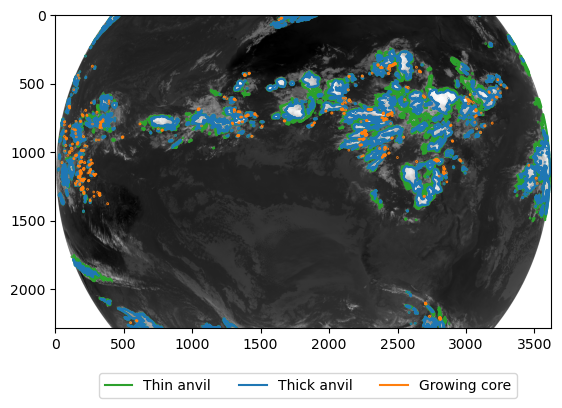

In [13]:
import matplotlib.lines as mlines
plt.imshow(dcc_ds.BT[80][::-1, ::-1], cmap="binary", vmin=190, vmax=310)
plt.contour(dcc_ds.thin_anvil_label[80][::-1, ::-1], levels=[0.5], colors=["C2"])
plt.contour(dcc_ds.thick_anvil_label[80][::-1, ::-1], levels=[0.5], colors=["C0"])
plt.contour(dcc_ds.core_label[80][::-1, ::-1], levels=[0.5], colors=["C1"])

plt.gcf().legend(
    [
        mlines.Line2D([], [], color='C2'), 
        mlines.Line2D([], [], color='C0'), 
        mlines.Line2D([], [], color='C1'), 
    ],
    [
        'Thin anvil', 'Thick anvil', 'Growing core', 
    ], 
    loc='center', ncol=3, bbox_to_anchor=[0.52, 0.05]
)

In [9]:
ec_path = pathlib.Path("/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2b/ACM_CAP_2B")

In [10]:
ec_files = sorted(list(ec_path.rglob("*_20240811*.h5")))

In [11]:
# ec_ds = xr.concat(
#     [xr.open_datatree(f).ScienceData.to_dataset().isel(JSG_height=slice(0,241)) for f in ec_files],
#     "along_track"
# )

In [12]:
ec_files[3]

PosixPath('/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2b/ACM_CAP_2B/2024/08/11/ECA_EXBA_ACM_CAP_2B_20240811T111013Z_20250905T170003Z_01159E.h5')

In [13]:
f = ec_files[3]
ec_ds = xr.open_datatree(f).ScienceData.to_dataset()

In [14]:
ec_ds

<xarray.Dataset> Size: 558MB
Dimensions:                                                         (
                                                                     along_track: 4929,
                                                                     JSG_height: 242,
                                                                     MSI_longwave_channel: 3,
                                                                     MSI_shortwave_channel: 1)
Dimensions without coordinates: along_track, JSG_height, MSI_longwave_channel,
                                MSI_shortwave_channel
Data variables: (12/192)
    time                                                            (along_track) datetime64[ns] 39kB ...
    latitude                                                        (along_track) float64 39kB ...
    longitude                                                       (along_track) float64 39kB ...
    height                                                          (along_track, JSG_height) float32 5MB ...
    geoid_offset                                                    (along_track) float32 20kB ...
    elevation                                                       (along_track) float32 20kB ...
    ...                                                              ...
    MSI_shortwave_observation_variable_count                        (along_track) int32 20kB ...
    MSI_shortwave_cost_function                                     (along_track) float32 20kB ...
    MSI_shortwave_wavelength                                        (MSI_shortwave_channel) float32 4B ...
    MSI_shortwave_albedo_forward                                    (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo                                            (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo_assimilation_status                        (along_track) int8 5kB ...

In [15]:
from pyproj import Proj

In [16]:
msg_projection = Proj("+proj=geos +h=35785863.0 +a=6378169.0 +b=6356583.8 +lon_0=0.0 +sweep=x")

In [17]:
ec_x, ec_y = msg_projection(ec_ds.longitude, ec_ds.latitude)

In [18]:
ec_x

array([3951968.0295314 , 3952143.10180518, 3952369.30517862, ...,
       3366730.1553083 , 3366347.28527804, 3365964.33738088],
      shape=(4929,))

In [19]:
wh_valid = np.logical_and(
    np.isfinite(ec_x), np.isfinite(ec_y)
)

In [20]:
ec_colocated = dcc_ds.sel(
    x=ec_ds.longitude.copy(data=ec_x)[wh_valid], 
    y=ec_ds.latitude.copy(data=ec_x)[wh_valid], 
    t=ec_ds.time[wh_valid], 
    method="nearest"
)

In [21]:
ec_colocated.thick_anvil_label.size

4929

In [22]:
ec_colocated.thick_anvil_label

<xarray.DataArray 'thick_anvil_label' (along_track: 4929)> Size: 20kB
[4929 values with dtype=int32]
Coordinates:
    t          (along_track) datetime64[ns] 39kB 2024-08-11T11:12:42.288000 ....
    y          (along_track) float64 39kB 3.429e+06 3.429e+06 ... 3.366e+06
    x          (along_track) float64 39kB 3.952e+06 3.952e+06 ... 3.366e+06
    longitude  (along_track) float64 39kB ...
    latitude   (along_track) float64 39kB ...
Dimensions without coordinates: along_track
Attributes:
    long_name:      labels for detected thick anvil regions
    cell_measures:  area: area
    units:          
    standard_name:  thick_anvil_label

In [23]:
ec_colocated.thick_anvil_label.any()

<xarray.DataArray 'thick_anvil_label' ()> Size: 1B
array(False)

In [34]:
ec_ds.time.min()

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-11T11:10:17.039474944', dtype='datetime64[ns]')

In [40]:
dcc_ds.t[52]

<xarray.DataArray 't' ()> Size: 8B
array('2024-08-11T11:12:42.288000000', dtype='datetime64[ns]')
Coordinates:
    t        datetime64[ns] 8B 2024-08-11T11:12:42.288000

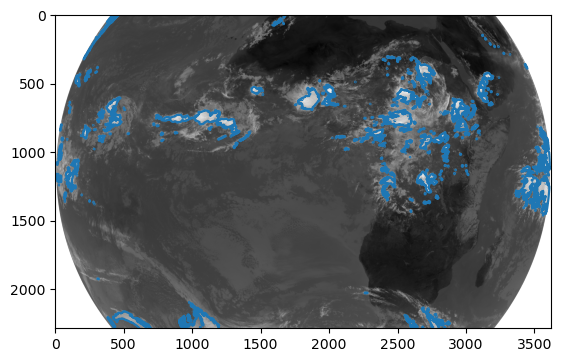

In [44]:
plt.imshow(dcc_ds.BT[52][::-1,::-1], cmap="binary")
# plt.contour(dcc_ds.thin_anvil_label[52][::-1,::-1], levels=[0.5], colors=["C2"])
plt.contour(dcc_ds.thick_anvil_label[52][::-1,::-1], levels=[0.5], colors=["C0"])
# plt.contour(dcc_ds.core_label[52][::-1,::-1], levels=[0.5], colors=["C1"])

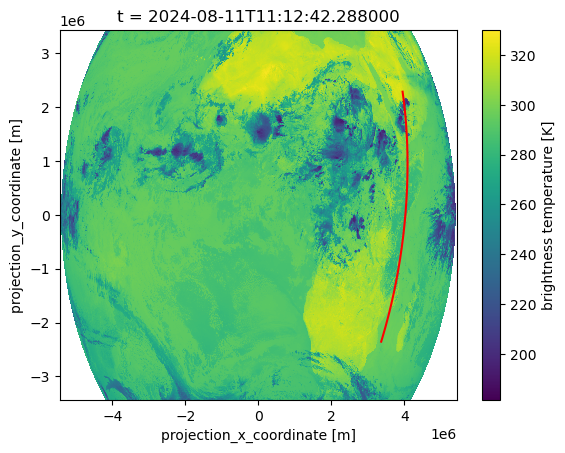

In [41]:
dcc_ds.BT[52].plot()
plt.plot(ec_x[wh_valid], ec_y[wh_valid], "r")

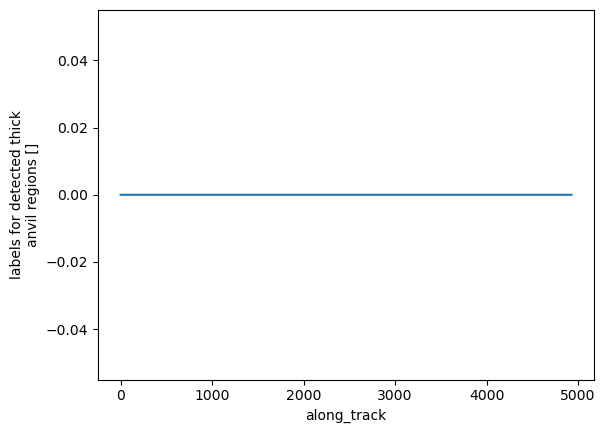

In [42]:
ec_colocated.thick_anvil_label.plot()

In [29]:
ec_x[wh_valid][wh_dcc]

array([], shape=(0, 4929), dtype=float64)

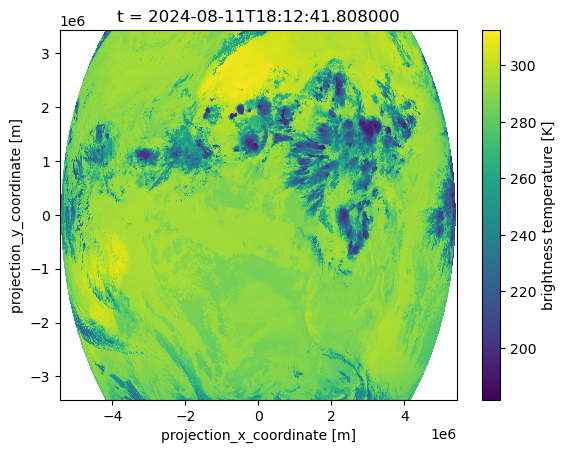

In [30]:
wh_dcc = ec_colocated.thick_anvil_label>0
dcc_ds.BT[80].plot()
plt.plot(ec_x[wh_valid][wh_dcc], ec_y[wh_valid][wh_dcc], "r")